### Part 5 - creating models
##### quick sar modeling for herg
##### regression + classification w rdkit fp + small desc
##### proper holdout test + 5 fold cv on train only

In [1]:
#imports
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, KFold, StratifiedKFold
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    precision_recall_fscore_support, brier_score_loss
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNet, LogisticRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.dummy import DummyRegressor, DummyClassifier
from sklearn.inspection import permutation_importance
from sklearn.calibration import calibration_curve

import matplotlib.pyplot as plt

from rdkit import Chem
from rdkit.Chem import Descriptors
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator
from rdkit.Chem import DataStructs

# config
data_path = "herg_postprocessed.csv" 

smiles_col = "canonical_smiles"
y_col = "pchembl_value_num"
rel_col = "standard_relation"
type_col = "standard_type"

allowed_types = {"IC50", "Ki"} # keep potency endpoints
allowed_rel = {"="}
active_thr = 5.0 # pIC50 >= 5 => active

fp_radius = 2
fp_nbits = 2048

random_seed = 42
feature_modes = ["fp", "desc", "fp_desc"]

desc_names = ["mw", "logp", "tpsa", "hbd", "hba", "rot_bonds", "ring_count"]
morgan_gen = GetMorganGenerator(radius=fp_radius, fpSize=fp_nbits)

In [2]:
# loading and filtering data
def load_measured_subset(path: str) -> pd.DataFrame:
    df = pd.read_csv(path)

    # measured-only, uncensored, IC50/Ki rows for decently high quality continuous ic50 data
    keep = (
        df[smiles_col].notna()
        & df[y_col].notna()
        & df[rel_col].astype(str).str.strip().isin(allowed_rel)
        & df[type_col].astype(str).str.strip().isin(allowed_types)
    )

    out = df.loc[keep, [smiles_col, y_col]].copy()
    out = out.rename(columns={smiles_col: "smiles", y_col: "y"})
    out["y"] = pd.to_numeric(out["y"], errors="coerce")
    out = out.dropna(subset=["y"]).reset_index(drop=True)
    out = out[out["smiles"].astype(str).str.len() > 0].reset_index(drop=True)
    return out

df = load_measured_subset(data_path)
print("rows after modeling filter:", len(df))
display(df["y"].describe())

rows after modeling filter: 1221


count    1221.00000
mean        5.84973
std         1.14472
min         4.00000
25%         5.00000
50%         5.65000
75%         6.58000
max         9.82000
Name: y, dtype: float64

In [3]:
# features
def featurize_one(smiles: str):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None, None

    # morgan fp radius=2, nbits=2048
    fp = morgan_gen.GetFingerprint(mol)
    fp_arr = np.zeros((fp_nbits,), dtype=np.int8)
    DataStructs.ConvertToNumpyArray(fp, fp_arr)

    # small descriptor set to compare against fingerprints + combined
    desc = np.array([
        Descriptors.MolWt(mol),
        Descriptors.MolLogP(mol),
        Descriptors.TPSA(mol),
        Descriptors.NumHDonors(mol),
        Descriptors.NumHAcceptors(mol),
        Descriptors.NumRotatableBonds(mol),
        Descriptors.RingCount(mol),
    ], dtype=np.float32)

    return fp_arr.astype(np.float32), desc

def build_features(df: pd.DataFrame):
    fps, descs, ys = [], [], []
    bad = 0

    for s, y in zip(df["smiles"].values, df["y"].values):
        fp, desc = featurize_one(s)
        if fp is None:
            bad += 1
            continue
        fps.append(fp)
        descs.append(desc)
        ys.append(float(y))

    if bad > 0:
        print("dropped", bad, "rows due to rdkit parse fail")

    return (
        np.asarray(fps, dtype=np.float32),
        np.asarray(descs, dtype=np.float32),
        np.asarray(ys, dtype=np.float32),
    )

def stack_features(fps, descs, mode: str):
    if mode == "fp":
        return fps
    if mode == "desc":
        return descs
    if mode == "fp_desc":
        return np.concatenate([fps, descs], axis=1)
    raise ValueError("unknown mode " + mode)

fps, descs, y = build_features(df)
y_bin = (y >= active_thr).astype(int)
print("class balance (fraction active):", float(y_bin.mean()))

class balance (fraction active): 0.7583947583947583


In [4]:
# useful helpers for plotting and metrics 
def reg_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    return {
        "rmse": float(np.sqrt(mse)),
        "mae": float(mean_absolute_error(y_true, y_pred)),
        "r2": float(r2_score(y_true, y_pred)),
    }

def cls_metrics(y_true, proba, thr=0.5):
    pred = (proba >= thr).astype(int)
    pr, rc, f1, _ = precision_recall_fscore_support(
        y_true, pred, average="binary", zero_division=0
    )
    return {
        "roc_auc": float(roc_auc_score(y_true, proba)),
        "pr_auc": float(average_precision_score(y_true, proba)),
        "precision": float(pr),
        "recall": float(rc),
        "f1": float(f1),
        "brier": float(brier_score_loss(y_true, proba)),
        "cm": confusion_matrix(y_true, pred),
    }

def cv_regression(model, x, y, n_splits=5):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_seed)
    rows = []
    for fold, (tr_idx, va_idx) in enumerate(kf.split(x), start=1):
        x_tr, x_va = x[tr_idx], x[va_idx]
        y_tr, y_va = y[tr_idx], y[va_idx]
        model.fit(x_tr, y_tr)
        pred = model.predict(x_va)
        m = reg_metrics(y_va, pred)
        m["fold"] = fold
        rows.append(m)
    return pd.DataFrame(rows)

def cv_classification(model, x, y, n_splits=5):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_seed)
    rows = []
    for fold, (tr_idx, va_idx) in enumerate(skf.split(x, y), start=1):
        x_tr, x_va = x[tr_idx], x[va_idx]
        y_tr, y_va = y[tr_idx], y[va_idx]
        model.fit(x_tr, y_tr)
        proba = model.predict_proba(x_va)[:, 1]
        m = cls_metrics(y_va, proba)
        m["fold"] = fold
        rows.append({k: v for k, v in m.items() if k != "cm"})
    return pd.DataFrame(rows)

def plot_roc_inline(y_true, proba, title):
    from sklearn.metrics import roc_curve
    fpr, tpr, _ = roc_curve(y_true, proba)
    plt.figure()
    plt.plot(fpr, tpr)
    plt.plot([0, 1], [0, 1])
    plt.xlabel("false positive rate")
    plt.ylabel("true positive rate")
    plt.title(title)
    plt.tight_layout()
    plt.show()

def plot_calibration_inline(y_true, proba, title, n_bins=10):
    frac_pos, mean_pred = calibration_curve(y_true, proba, n_bins=n_bins, strategy="uniform")
    plt.figure()
    plt.plot(mean_pred, frac_pos, marker="o")
    plt.plot([0, 1], [0, 1])
    plt.xlabel("mean predicted prob")
    plt.ylabel("fraction positives")
    plt.title(title)
    plt.tight_layout()
    plt.show()

def make_feature_names(mode: str):
    if mode == "fp":
        return [f"fp_bit_{i}" for i in range(fp_nbits)]
    if mode == "desc":
        return list(desc_names)
    if mode == "fp_desc":
        return [f"fp_bit_{i}" for i in range(fp_nbits)] + list(desc_names)
    raise ValueError("unknown mode " + mode)

def top_perm_importance(estimator, x_test, y_test, feature_names, task: str, n_top=20):
    scoring = "neg_root_mean_squared_error" if task == "reg" else "roc_auc"
    imp = permutation_importance(
        estimator, x_test, y_test,
        n_repeats=10, random_state=random_seed,
        scoring=scoring, n_jobs=-1
    )
    im = imp.importances_mean
    order = np.argsort(-im)[:n_top]
    return pd.DataFrame({
        "feature": [feature_names[i] for i in order],
        "importance": [float(im[i]) for i in order]
    })

In [5]:
# train test split
idx_all = np.arange(len(y))

# holding out test + cv only inside train to avoid leakage
idx_tr_reg, idx_te_reg = train_test_split(idx_all, test_size=0.2, random_state=random_seed)
idx_tr_cls, idx_te_cls = train_test_split(idx_all, test_size=0.2, random_state=random_seed, stratify=y_bin)

print("reg train/test:", len(idx_tr_reg), len(idx_te_reg))
print("cls train/test:", len(idx_tr_cls), len(idx_te_cls))

reg train/test: 976 245
cls train/test: 976 245


In [6]:
#regression 

reg_rows = []

base_reg = DummyRegressor(strategy="mean")
reg_model = Pipeline([
    ("scaler", StandardScaler(with_mean=True, with_std=True)),
    ("enet", ElasticNet(alpha=0.01, l1_ratio=0.5, random_state=random_seed, max_iter=10000))
])

for mode in feature_modes:
    x = stack_features(fps, descs, mode)
    x_tr, x_te = x[idx_tr_reg], x[idx_te_reg]
    y_tr, y_te = y[idx_tr_reg], y[idx_te_reg]

    # baseline mean + cv
    cv_df = cv_regression(base_reg, x_tr, y_tr, n_splits=5)
    cv_sum = cv_df[["rmse", "mae", "r2"]].agg(["mean", "std"])
    base_reg.fit(x_tr, y_tr)
    pred = base_reg.predict(x_te)
    m = reg_metrics(y_te, pred)

    reg_rows.append({
        "model": "baseline_mean",
        "features": mode,
        **m,
        "cv_rmse_mean": float(cv_sum.loc["mean", "rmse"]),
        "cv_rmse_std": float(cv_sum.loc["std", "rmse"]),
        "cv_mae_mean": float(cv_sum.loc["mean", "mae"]),
        "cv_mae_std": float(cv_sum.loc["std", "mae"]),
        "cv_r2_mean": float(cv_sum.loc["mean", "r2"]),
        "cv_r2_std": float(cv_sum.loc["std", "r2"]),
    })

    # elasticnet + cv
    cv_df = cv_regression(reg_model, x_tr, y_tr, n_splits=5)
    cv_sum = cv_df[["rmse", "mae", "r2"]].agg(["mean", "std"])
    reg_model.fit(x_tr, y_tr)
    pred = reg_model.predict(x_te)
    m = reg_metrics(y_te, pred)

    reg_rows.append({
        "model": "elasticnet",
        "features": mode,
        **m,
        "cv_rmse_mean": float(cv_sum.loc["mean", "rmse"]),
        "cv_rmse_std": float(cv_sum.loc["std", "rmse"]),
        "cv_mae_mean": float(cv_sum.loc["mean", "mae"]),
        "cv_mae_std": float(cv_sum.loc["std", "mae"]),
        "cv_r2_mean": float(cv_sum.loc["mean", "r2"]),
        "cv_r2_std": float(cv_sum.loc["std", "r2"]),
    })

reg_table = pd.DataFrame(reg_rows).sort_values(["model", "features"]).reset_index(drop=True)
display(reg_table)

,model,features,rmse,mae,r2,cv_rmse_mean,cv_rmse_std,cv_mae_mean,cv_mae_std,cv_r2_mean,cv_r2_std
0,baseline_mean,desc,1.122752,0.921296,-0.001310,1.149085,0.056883,0.936499,0.053324,-0.002991,0.004080
1,baseline_mean,fp,1.122752,0.921296,-0.001310,1.149085,0.056883,0.936499,0.053324,-0.002991,0.004080
2,baseline_mean,fp_desc,1.122752,0.921296,-0.001310,1.149085,0.056883,0.936499,0.053324,-0.002991,0.004080
3,elasticnet,desc,1.190686,0.904033,-0.126147,1.473480,0.798169,0.926848,0.084747,-1.086932,2.571192
4,elasticnet,fp,0.852548,0.572904,0.422651,0.851999,0.050925,0.592758,0.041811,0.442946,0.092524
5,elasticnet,fp_desc,0.840244,0.558135,0.439195,1.001334,0.382641,0.608046,0.085067,0.130499,0.779529


In [7]:
# reg importance
# rf is just for a simple importance view, model we report is elasticnet
x_reg = stack_features(fps, descs, "fp_desc")
x_tr, x_te = x_reg[idx_tr_reg], x_reg[idx_te_reg]
y_tr, y_te = y[idx_tr_reg], y[idx_te_reg]

rf_reg = RandomForestRegressor(n_estimators=400, random_state=random_seed, n_jobs=-1)
rf_reg.fit(x_tr, y_tr)

reg_imp = top_perm_importance(
    rf_reg, x_te, y_te,
    feature_names=make_feature_names("fp_desc"),
    task="reg",
    n_top=20
)
display(reg_imp)

,feature,importance
0,logp,0.067838
1,fp_bit_1683,0.057393
2,fp_bit_894,0.053299
3,tpsa,0.050551
4,fp_bit_1791,0.047873
5,fp_bit_1514,0.029506
6,fp_bit_1482,0.018283
7,fp_bit_1863,0.010864
8,fp_bit_90,0.008256
9,fp_bit_1647,0.007263


In [8]:
#classification
cls_rows = []

base_cls = DummyClassifier(strategy="most_frequent")
cls_model = Pipeline([
    ("scaler", StandardScaler(with_mean=True, with_std=True)),
    ("lr", LogisticRegression(max_iter=4000, class_weight="balanced", random_state=random_seed))
])

test_outputs = {}

for mode in feature_modes:
    x = stack_features(fps, descs, mode)
    x_tr, x_te = x[idx_tr_cls], x[idx_te_cls]
    y_tr, y_te = y_bin[idx_tr_cls], y_bin[idx_te_cls]

    # baseline majority + cv
    cv_df = cv_classification(base_cls, x_tr, y_tr, n_splits=5)
    cv_sum = cv_df[["roc_auc", "pr_auc", "f1", "brier"]].agg(["mean", "std"])
    base_cls.fit(x_tr, y_tr)
    proba = base_cls.predict_proba(x_te)[:, 1]
    m = cls_metrics(y_te, proba)

    cls_rows.append({
        "model": "baseline_majority",
        "features": mode,
        **{k: v for k, v in m.items() if k != "cm"},
        "cv_roc_auc_mean": float(cv_sum.loc["mean", "roc_auc"]),
        "cv_roc_auc_std": float(cv_sum.loc["std", "roc_auc"]),
        "cv_pr_auc_mean": float(cv_sum.loc["mean", "pr_auc"]),
        "cv_pr_auc_std": float(cv_sum.loc["std", "pr_auc"]),
        "cv_f1_mean": float(cv_sum.loc["mean", "f1"]),
        "cv_f1_std": float(cv_sum.loc["std", "f1"]),
        "cv_brier_mean": float(cv_sum.loc["mean", "brier"]),
        "cv_brier_std": float(cv_sum.loc["std", "brier"]),
    })

    # logreg balanced + cv
    cv_df = cv_classification(cls_model, x_tr, y_tr, n_splits=5)
    cv_sum = cv_df[["roc_auc", "pr_auc", "f1", "brier"]].agg(["mean", "std"])
    cls_model.fit(x_tr, y_tr)
    proba = cls_model.predict_proba(x_te)[:, 1]
    m = cls_metrics(y_te, proba)

    cls_rows.append({
        "model": "logreg_balanced",
        "features": mode,
        **{k: v for k, v in m.items() if k != "cm"},
        "cv_roc_auc_mean": float(cv_sum.loc["mean", "roc_auc"]),
        "cv_roc_auc_std": float(cv_sum.loc["std", "roc_auc"]),
        "cv_pr_auc_mean": float(cv_sum.loc["mean", "pr_auc"]),
        "cv_pr_auc_std": float(cv_sum.loc["std", "pr_auc"]),
        "cv_f1_mean": float(cv_sum.loc["mean", "f1"]),
        "cv_f1_std": float(cv_sum.loc["std", "f1"]),
        "cv_brier_mean": float(cv_sum.loc["mean", "brier"]),
        "cv_brier_std": float(cv_sum.loc["std", "brier"]),
    })

    print("\nlogreg test cm (" + mode + ")")
    print(m["cm"])

    test_outputs[mode] = (y_te, proba)

cls_table = pd.DataFrame(cls_rows).sort_values(["model", "features"]).reset_index(drop=True)
display(cls_table)


logreg test cm (fp)
[[ 37  22]
 [ 18 168]]

logreg test cm (desc)
[[ 36  23]
 [ 61 125]]

logreg test cm (fp_desc)
[[ 37  22]
 [ 17 169]]


,model,features,roc_auc,pr_auc,precision,recall,f1,brier,cv_roc_auc_mean,cv_roc_auc_std,cv_pr_auc_mean,cv_pr_auc_std,cv_f1_mean,cv_f1_std,cv_brier_mean,cv_brier_std
0,baseline_majority,desc,0.500000,0.759184,0.759184,1.000000,0.863109,0.240816,0.500000,0.000000,0.758200,0.001732,0.862472,0.001122,0.241800,0.001732
1,baseline_majority,fp,0.500000,0.759184,0.759184,1.000000,0.863109,0.240816,0.500000,0.000000,0.758200,0.001732,0.862472,0.001122,0.241800,0.001732
2,baseline_majority,fp_desc,0.500000,0.759184,0.759184,1.000000,0.863109,0.240816,0.500000,0.000000,0.758200,0.001732,0.862472,0.001122,0.241800,0.001732
3,logreg_balanced,desc,0.702342,0.889640,0.844595,0.672043,0.748503,0.213798,0.678837,0.022181,0.867365,0.013147,0.695961,0.019717,0.226972,0.004351
4,logreg_balanced,fp,0.857664,0.943441,0.884211,0.903226,0.893617,0.142686,0.856657,0.013783,0.933258,0.008122,0.894118,0.022414,0.139149,0.028486
5,logreg_balanced,fp_desc,0.858757,0.943524,0.884817,0.908602,0.896552,0.142198,0.857718,0.014557,0.934030,0.008104,0.894118,0.022414,0.138963,0.028226


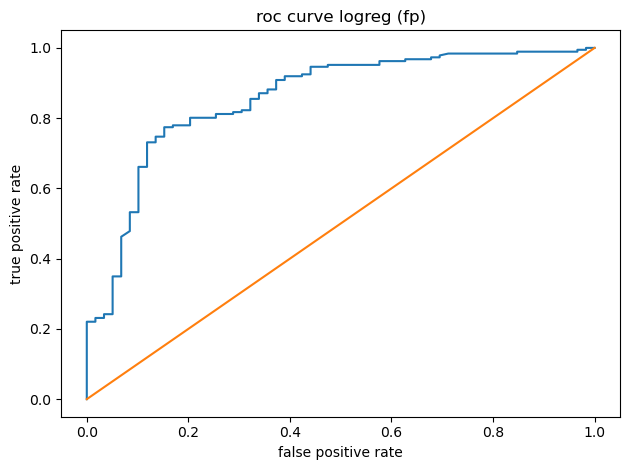

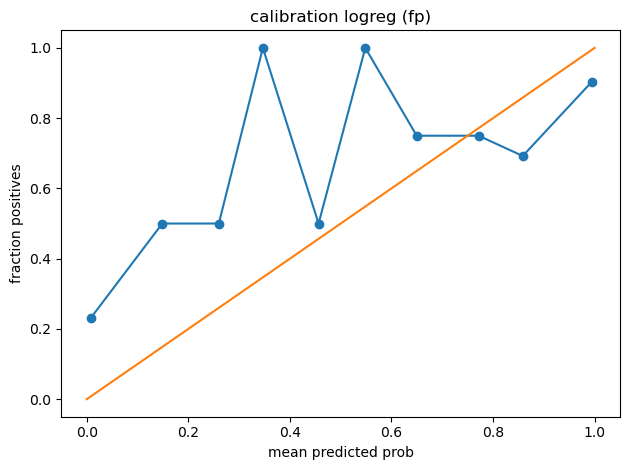

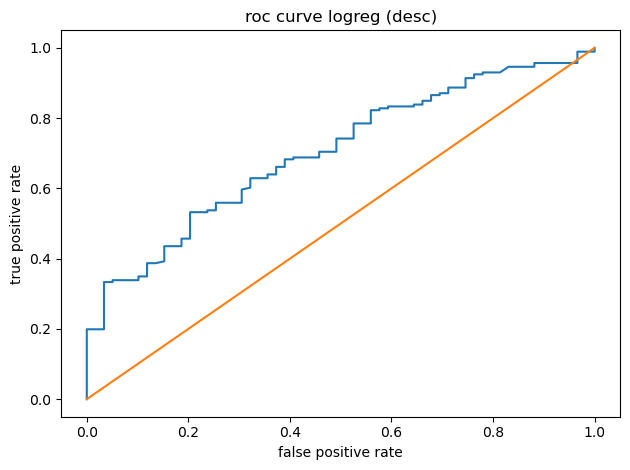

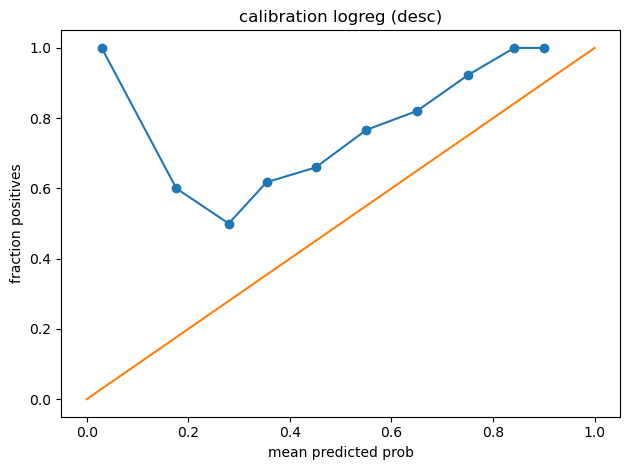

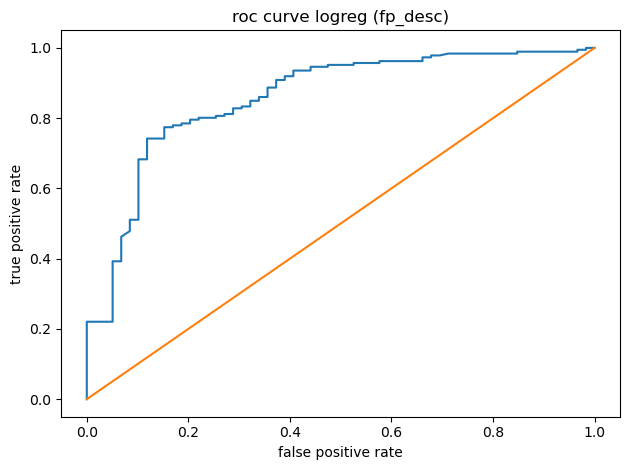

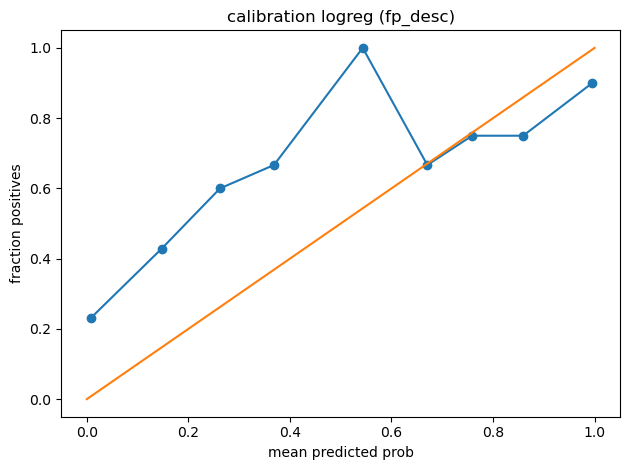

In [9]:
# roc and calibration plots
for mode in feature_modes:
    y_te, proba = test_outputs[mode]
    plot_roc_inline(y_te, proba, f"roc curve logreg ({mode})")
    plot_calibration_inline(y_te, proba, f"calibration logreg ({mode})")

In [10]:
# classification importance (perm on fp_desc)
x_cls = stack_features(fps, descs, "fp_desc")
x_tr, x_te = x_cls[idx_tr_cls], x_cls[idx_te_cls]
y_tr, y_te = y_bin[idx_tr_cls], y_bin[idx_te_cls]

cls_model.fit(x_tr, y_tr)

cls_imp = top_perm_importance(
    cls_model, x_te, y_te,
    feature_names=make_feature_names("fp_desc"),
    task="cls",
    n_top=20
)
display(cls_imp)

,feature,importance
0,fp_bit_2,0.009245
1,fp_bit_456,0.007846
2,fp_bit_560,0.005431
3,fp_bit_90,0.005385
4,fp_bit_1538,0.004474
5,fp_bit_546,0.004146
6,fp_bit_13,0.003950
7,fp_bit_1452,0.003604
8,fp_bit_1011,0.003522
9,fp_bit_1964,0.003403


### Part 6 - Uncertainty, Bias, Limitations

Assay heterogeneity hurts generalization. hERG activity comes from different labs and assay formats with different protocols, cell lines, temperatures, and analysis pipelines. The same molecule can therefore have different IC50 or Ki values depending on conditions. Even after converting values onto a p-scale, those experimental differences remain baked into the labels, which adds noise and can reduce out-of-distribution performance. We tried to reduce this by filtering to potency endpoints (IC50 and Ki) and using only standard_relation = = for the regression target, but heterogeneity still exists within that subset.

Dataset imbalance can bias the classifier. With the pIC50 ≥ 5 threshold, the dataset is active-heavy (about 0.76 active), so some metrics like PR AUC can look strong even when the model is mostly learning the majority pattern. We used stratified train/test splits and stratified cross-validation so the class ratio stays consistent across folds. We also used class_weight = balanced in logistic regression to reduce the tendency to over-predict the majority class.

Censoring and duplicates are ongoing risks. Real bioactivity tables contain inequalities (<, >), and dropping censored values can bias the regression task toward the measurable mid-range while removing hard negatives or very potent compounds. Duplicated or repeated measurements can also inflate performance if similar entries leak across train and test. We mitigated this by filtering to uncensored equals rows for regression, using a holdout test set, and running 5-fold CV only inside the training split. We also included required baselines (mean predictor for regression, majority class for classification) to verify that the models are learning beyond trivial heuristics.

Some limitations remain. We did not use scaffold splitting, so random splitting may still be optimistic if close analogs appear on both sides of the split. We excluded censored rows instead of modeling censoring explicitly, so the regression task is cleaner but less representative of real screening settings. We also did not enforce a group split by compound identity, so near-duplicates or related series could still leak across splits. Finally, fingerprint bit feature importance is mainly a diagnostic signal and should not be treated as a mechanistic explanation of hERG binding or safety risk.